# Fase 3 — Regras de Associação: Candidatos 2026 (TSE)

## Pergunta de negócio

> **Que combinações de características dos candidatos aparecem juntas com mais frequência do que se fossem independentes? Em particular: quais atributos (partido, gênero, escolaridade, cor/raça, UF de nascimento) estão associados a cada perfil identificado na Fase 2 — e, assim que a eleição ocorrer, a ser eleito?**

Até aqui, a clusterização (Fase 2) agrupou candidatos por **distância** em variáveis numéricas (idade, escolaridade, patrimônio). Regras de associação fazem uma pergunta diferente: em vez de "quem está perto de quem", **quais combinações de atributos categóricos aparecem juntas com mais frequência do que o acaso explicaria**? A técnica clássica pra isso é o **Apriori**, que originalmente resolve o problema da "cesta de compras" (que produtos são comprados juntos) — aqui, cada candidato é uma cesta, e cada valor de cada variável categórica (partido, gênero, escolaridade...) é um item dessa cesta.


## Configuração

Use os **mesmos valores** que você usou nas Fases 0/1/2, para carregar o arquivo certo.


In [3]:
from google.colab import drive
drive.mount('/content/drive')

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

Mounted at /content/drive


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

In [1]:
CARGO = "DEPUTADO FEDERAL"
UF = ["SP", "RJ", "MG", "ES"]               # mesmo valor usado na Fase 0/1, 0/1/2
ANO_ELEICAO = 2026


## Preparando a base — reconstituindo os clusters nomeados da Fase 2

Apriori precisa de **itens categóricos**, não de distância — mas queremos incluir o cluster da Fase 2 como mais um item da cesta (pra achar regras do tipo "esse perfil de candidato é dos Abastados"). Na Fase 2 (`02_clusterizacao.ipynb`), o **Bisecting K-Means com k=3** (critério de inércia média) foi o resultado final escolhido, e os três clusters foram batizados a partir da ficha técnica e da composição demográfica/partidária:

- **Abastados** — 78% dos candidatos, os únicos com algum patrimônio declarado.
- **Jovens** — o grupo mais novo (39 anos em média), quase sem patrimônio declarado.
- **Sem bens e alta escolaridade** — 100% sem patrimônio declarado, a maior escolaridade média dos três (e também o grupo mais velho).

Recalculamos aqui, rapidamente, a mesma partição (mesma `SEMENTE`, mesmo critério, mesmos nomes) — mesma lógica de auto-suficiência já usada no `02_clusterizacao_outros.ipynb`.


In [23]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from mlxtend.frequent_patterns import apriori, association_rules

!pip install pyvis # Install pyvis library
from pyvis.network import Network
from IPython.display import IFrame

sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)  # não truncar antecedents/consequents nas tabelas

SEMENTE = 42
np.random.seed(SEMENTE)  # mesmo racional de reprodutibilidade defensiva dos notebooks anteriores

nome_cargo = CARGO.replace(' ', '_')

# Formatação corrigida para corresponder ao nome real do ficheiro
if UF is not None:
    if isinstance(UF, list):
        # Gera o formato ('SP', 'RJ', 'MG', 'ES')
        nome_uf_formatted = str(tuple(UF))
    else:
        nome_uf_formatted = UF
else:
    nome_uf_formatted = 'BRASIL'

arquivo = f"/content/drive/MyDrive/dados/candidatos_{nome_cargo}_{nome_uf_formatted}_{ANO_ELEICAO}.csv"

df = pd.read_csv(arquivo)
print(f"Carregado: {arquivo}  ->  {df.shape[0]} candidatos, {df.shape[1]} colunas")
df.head()

Carregado: /content/drive/MyDrive/dados/candidatos_DEPUTADO_FEDERAL_('SP', 'RJ', 'MG', 'ES')_2026.csv  ->  2800 candidatos, 59 colunas


,DT_GERACAO,HH_GERACAO,ANO_ELEICAO,CD_TIPO_ELEICAO,NM_TIPO_ELEICAO,NR_TURNO,CD_ELEICAO,DS_ELEICAO,DT_ELEICAO,TP_ABRANGENCIA,SG_UF,SG_UE,NM_UE,CD_CARGO,DS_CARGO,SQ_CANDIDATO,NR_CANDIDATO,NM_CANDIDATO,NM_URNA_CANDIDATO,NM_SOCIAL_CANDIDATO,NR_CPF_CANDIDATO,DS_EMAIL,CD_SITUACAO_CANDIDATURA,DS_SITUACAO_CANDIDATURA,TP_AGREMIACAO,NR_PARTIDO,SG_PARTIDO,NM_PARTIDO,NR_FEDERACAO,NM_FEDERACAO,SG_FEDERACAO,DS_COMPOSICAO_FEDERACAO,SQ_COLIGACAO,NM_COLIGACAO,DS_COMPOSICAO_COLIGACAO,SG_UF_NASCIMENTO,DT_NASCIMENTO,NR_TITULO_ELEITORAL_CANDIDATO,CD_GENERO,DS_GENERO,CD_GRAU_INSTRUCAO,DS_GRAU_INSTRUCAO,CD_ESTADO_CIVIL,DS_ESTADO_CIVIL,CD_COR_RACA,DS_COR_RACA,CD_OCUPACAO,DS_OCUPACAO,CD_SIT_TOT_TURNO,DS_SIT_TOT_TURNO,BENS IMÓVEIS,BENS MÓVEIS,DINHEIRO,INVESTIMENTOS RENDA FIXA,INVESTIMENTOS RENDA VARIÁVEL,OUTROS BENS,Total_Bens,Total_Bens_Log,IDADE
0,27/08/2026,12:30:35,2026,2,ELEIÇÃO ORDINÁRIA,1,6259,Eleições Gerais Estaduais 2026,2026-10-04,ESTADUAL,ES,ES,ESPÍRITO SANTO,6,DEPUTADO FEDERAL,80002531643,3090,JOÃO BATISTA DE ASSIS,SARGENTO ASSIS,#NULO,3152826737,NÃO DIVULGÁVEL,-3,#NE,PARTIDO ISOLADO,30,NOVO,PARTIDO NOVO,-1,#NULO,#NULO,#NULO,80001800054,PARTIDO ISOLADO,NOVO,ES,1974-03-23,14740511465,2,MASCULINO,8,SUPERIOR COMPLETO,3,CASADO(A),2,PRETA,278,VEREADOR,-1,#NULO,400000.0,92500.0,0.0,0.0,0.0,0.0,492500.0,13.107252,52
1,27/08/2026,12:30:35,2026,2,ELEIÇÃO ORDINÁRIA,1,6259,Eleições Gerais Estaduais 2026,2026-10-04,ESTADUAL,ES,ES,ESPÍRITO SANTO,6,DEPUTADO FEDERAL,80002531644,3010,FABÍOLA SAQUETTO DI TOMMASO,FABÍOLA SAQUETTO,#NULO,7106495760,NÃO DIVULGÁVEL,-3,#NE,PARTIDO ISOLADO,30,NOVO,PARTIDO NOVO,-1,#NULO,#NULO,#NULO,80001800054,PARTIDO ISOLADO,NOVO,ES,1977-08-06,17880711481,4,FEMININO,8,SUPERIOR COMPLETO,5,VIÚVO(A),1,BRANCA,257,EMPRESÁRIO,-1,#NULO,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.000000,49
2,27/08/2026,12:30:35,2026,2,ELEIÇÃO ORDINÁRIA,1,6259,Eleições Gerais Estaduais 2026,2026-10-04,ESTADUAL,ES,ES,ESPÍRITO SANTO,6,DEPUTADO FEDERAL,80002531645,3060,AILANA REGINA PELISSARI SIMONELLI MOREIRA,AILANA PELISSARI,#NULO,9365295718,NÃO DIVULGÁVEL,-3,#NE,PARTIDO ISOLADO,30,NOVO,PARTIDO NOVO,-1,#NULO,#NULO,#NULO,80001800054,PARTIDO ISOLADO,NOVO,ES,1978-11-28,19854371449,4,FEMININO,8,SUPERIOR COMPLETO,1,SOLTEIRO(A),3,PARDA,999,OUTROS,-1,#NULO,0.0,0.0,0.0,0.0,0.0,60000.0,60000.0,11.002117,47
3,27/08/2026,12:30:35,2026,2,ELEIÇÃO ORDINÁRIA,1,6259,Eleições Gerais Estaduais 2026,2026-10-04,ESTADUAL,ES,ES,ESPÍRITO SANTO,6,DEPUTADO FEDERAL,80002531646,3040,JÚLIO CÉSAR COSTA CAIADO,DR. JÚLIO CAIADO,#NULO,33301018653,NÃO DIVULGÁVEL,-3,#NE,PARTIDO ISOLADO,30,NOVO,PARTIDO NOVO,-1,#NULO,#NULO,#NULO,80001800054,PARTIDO ISOLADO,NOVO,ES,1959-04-17,11524561414,2,MASCULINO,8,SUPERIOR COMPLETO,9,DIVORCIADO(A),1,BRANCA,112,VETERINÁRIO,-1,#NULO,900000.0,115000.0,0.0,0.0,0.0,0.0,1015000.0,13.830400,67
4,27/08/2026,12:30:35,2026,2,ELEIÇÃO ORDINÁRIA,1,6259,Eleições Gerais Estaduais 2026,2026-10-04,ESTADUAL,ES,ES,ESPÍRITO SANTO,6,DEPUTADO FEDERAL,80002531647,3033,LEONARDO RODRIGO NASCIMENTO,LÉO SINDICO,#NULO,7877752741,NÃO DIVULGÁVEL,-3,#NE,PARTIDO ISOLADO,30,NOVO,PARTIDO NOVO,-1,#NULO,#NULO,#NULO,80001800054,PARTIDO ISOLADO,NOVO,ES,1979-11-14,19497891406,2,MASCULINO,8,SUPERIOR COMPLETO,1,SOLTEIRO(A),3,PARDA,257,EMPRESÁRIO,-1,#NULO,300000.0,52000.0,0.0,0.0,0.0,0.0,352000.0,12.771389,46


In [24]:
# 1. Carregar o dataset de despesas ajustando o encoding e separador
caminho_despesas = "/content/drive/MyDrive/dados/despesas_contratadas_candidatos_2026_BRASIL.csv"
df_dc_final = pd.read_csv(caminho_despesas, encoding='latin1', sep=';')

# 2. Garantir que as chaves de junção (SQ_CANDIDATO) estão no mesmo formato (string)
df['SQ_CANDIDATO'] = df['SQ_CANDIDATO'].astype(str).str.strip()
df_dc_final['SQ_CANDIDATO'] = df_dc_final['SQ_CANDIDATO'].astype(str).str.strip()

# 3. Converter a coluna de valores para float
if df_dc_final['VR_DESPESA_CONTRATADA'].dtype == 'object':
    df_dc_final['VR_DESPESA_CONTRATADA'] = (
        df_dc_final['VR_DESPESA_CONTRATADA']
        .astype(str)
        .str.replace('.', '', regex=False)
        .str.replace(',', '.', regex=False)
    )
df_dc_final['VR_DESPESA_CONTRATADA'] = pd.to_numeric(df_dc_final['VR_DESPESA_CONTRATADA'], errors='coerce').fillna(0)

# 4. Agrupar por SQ_CANDIDATO e calcular o total
df_despesas_totais = (
    df_dc_final.groupby('SQ_CANDIDATO')['VR_DESPESA_CONTRATADA']
    .sum()
    .reset_index()
    .rename(columns={'VR_DESPESA_CONTRATADA': 'Total_Despesas'})
)

# 5. Remover a coluna se já existia de execuções anteriores para evitar duplicados (ex: Total_Despesas_x)
if 'Total_Despesas' in df.columns:
    df.drop(columns=['Total_Despesas'], inplace=True)

# 6. Fazer a junção (merge)
df = df.merge(df_despesas_totais, on='SQ_CANDIDATO', how='left')

# 7. Tratar nulos e calcular a transformação logarítmica
df['Total_Despesas'] = df['Total_Despesas'].fillna(0)
df['Total_Despesas_Log'] = np.log1p(df['Total_Despesas'])

print("Variável Total_Despesas adicionada com sucesso!\n")
print(df[['SQ_CANDIDATO', 'Total_Despesas', 'Total_Despesas_Log']].head())

Variável Total_Despesas adicionada com sucesso!

  SQ_CANDIDATO  Total_Despesas  Total_Despesas_Log
0  80002531643            0.00            0.000000
1  80002531644         3750.00            8.229778
2  80002531645         5000.00            8.517393
3  80002531646            9.95            2.393339
4  80002531647         5275.19            8.570960


In [25]:
ANOS_ESTUDO_POR_GRAU = {
    'ANALFABETO': 0,
    'LÊ E ESCREVE': 1,
    'ENSINO FUNDAMENTAL INCOMPLETO': 4,
    'ENSINO FUNDAMENTAL COMPLETO': 8,
    'ENSINO MÉDIO INCOMPLETO': 9,
    'ENSINO MÉDIO COMPLETO': 11,
    'SUPERIOR INCOMPLETO': 13,
    'SUPERIOR COMPLETO': 16,
    # 'NÃO DIVULGÁVEL' fica de fora de propósito — mesma decisão da Versão 2 do notebook de clusterização
}

df['ANOS_ESTUDO'] = df['DS_GRAU_INSTRUCAO'].map(ANOS_ESTUDO_POR_GRAU)


In [26]:
colunas_driver = ['IDADE', 'ANOS_ESTUDO', 'Total_Bens_Log', 'Total_Despesas_Log']

Q1, Q3 = df['Total_Bens_Log'].quantile([0.25, 0.75])
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR

df_cluster = df[(df['Total_Bens_Log'] <= limite_superior) & (df['ANOS_ESTUDO'].notna())].copy()
print(f"Base para clusterização/regras: {df_cluster.shape[0]} candidatos "
      f"(descartados {df.shape[0] - df_cluster.shape[0]} por patrimônio extremo ou escolaridade não divulgada)")

scaler = MinMaxScaler()
X = scaler.fit_transform(df_cluster[colunas_driver])


Base para clusterização/regras: 2800 candidatos (descartados 0 por patrimônio extremo ou escolaridade não divulgada)


In [62]:

def inercia(indices):
    if len(indices) < 2:
        return 0.0
    pontos = X[indices]
    centro = pontos.mean(axis=0)
    return float(((pontos - centro) ** 2).sum(axis=1).mean())


def bisecting_kmeans_ate_k(X, k_max, random_state=SEMENTE):
    """Mesma lógica do 02_clusterizacao.ipynb (Parte 2, critério de inércia média) — mas só
    devolve a partição final em k_max clusters, sem guardar o histórico de divisões (essa
    exploração já foi feita e documentada lá)."""
    clusters = {0: np.arange(X.shape[0])}
    proximo_id = 1
    for _ in range(1, k_max):
        id_escolhido = max(clusters, key=lambda cid: len(clusters[cid]))
        indices_pai = clusters[id_escolhido]
        if len(indices_pai) < 2:
            break
        km2 = KMeans(n_clusters=2, random_state=random_state, n_init=10)
        labels2 = km2.fit_predict(X[indices_pai])
        id_a, id_b = proximo_id, proximo_id + 1
        proximo_id += 2
        del clusters[id_escolhido]
        clusters[id_a] = indices_pai[labels2 == 0]
        clusters[id_b] = indices_pai[labels2 == 1]
    return clusters


k_bisecting = 4  # mesmo k escolhido no 02_clusterizacao.ipynb (Parte 2)

clusters_finais = bisecting_kmeans_ate_k(X, k_bisecting)
ids_por_tamanho = sorted(clusters_finais, key=lambda cid: len(clusters_finais[cid]), reverse=True)

rotulos = np.empty(X.shape[0], dtype=object)
for letra, cid in zip([chr(65 + i) for i in range(len(ids_por_tamanho))], ids_por_tamanho):
    rotulos[clusters_finais[cid]] = letra
df_cluster['cluster_bisecting'] = rotulos

# mesmos nomes definidos no 02_clusterizacao.ipynb, a partir da mesma ficha técnica
NOMES_CLUSTER_BISECTING = {
    'A': 'Elite Financeira e Eleitoral',
    'B': 'Acadêmicos de Baixo Orçamento',
    'C': 'Financiados Sem Patrimônio',
    'D': 'Perfil Tradicional'
    #'E': '...'
}
df_cluster['cluster'] = df_cluster['cluster_bisecting'].map(NOMES_CLUSTER_BISECTING)

df_cluster['cluster'].value_counts()


,count
cluster,
Elite Financeira e Eleitoral,1127
Acadêmicos de Baixo Orçamento,795
Financiados Sem Patrimônio,515
Perfil Tradicional,363


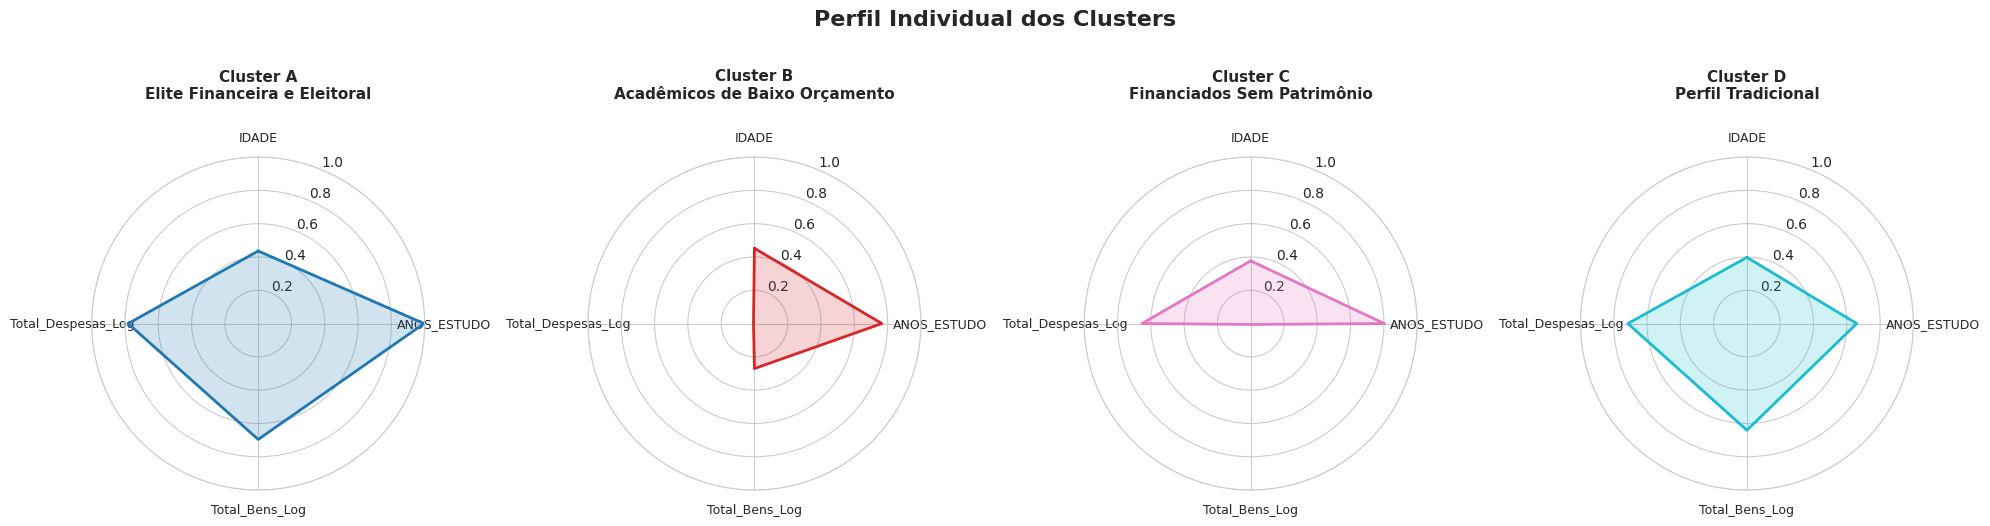

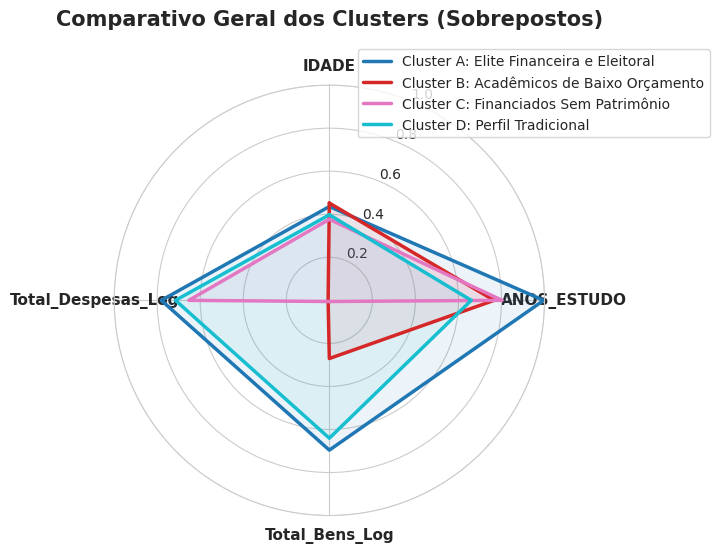

In [63]:
from math import pi
import matplotlib.pyplot as plt
import numpy as np

# --- 1. CONFIGURAÇÕES GERAIS ---
k_bisecting = 4
letras_ordenadas = [chr(65 + i) for i in range(k_bisecting)]  # Gera ['A', 'B', 'C', 'D', 'E']

cols_radar = ['IDADE', 'ANOS_ESTUDO', 'Total_Bens_Log', 'Total_Despesas_Log']

cores_radar = {
    'A': '#1f77b4',  # Azul
    'B': '#d62728',  # Vermelho
    'C': '#e377c2',  # Rosa
    'D': '#17becf',  # Ciano
    'E': '#ff7f0e'   # Laranja
}

# --- 2. CÁLCULO E NORMALIZAÇÃO DOS CENTROIDES ---
df_radar = df_cluster[cols_radar].copy()
df_radar = (df_radar - df_radar.min()) / (df_radar.max() - df_radar.min())
df_radar['cluster_letra'] = df_cluster['cluster_bisecting']

centroides_df = df_radar.groupby('cluster_letra')[cols_radar].mean().loc[letras_ordenadas]

# Preparação dos ângulos
n_eixos = len(cols_radar)
angulos = [n / float(n_eixos) * 2 * pi for n in range(n_eixos)]
angulos += angulos[:1]  # Fechar o polígono


# ==============================================================================
# PARTE 1: GRÁFICOS SEPARADOS (UM RADAR POR CLUSTER)
# ==============================================================================
ncols = 3 if k_bisecting > 4 else 4
nrows = -(-k_bisecting // ncols)

fig_sep, axes_sep = plt.subplots(
    nrows, ncols, figsize=(5 * ncols, 5 * nrows), subplot_kw=dict(polar=True)
)
axes_sep = np.array(axes_sep).flatten() if k_bisecting > 1 else [axes_sep]

for i, letra in enumerate(letras_ordenadas):
    ax = axes_sep[i]
    ax.set_theta_offset(pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angulos[:-1])
    ax.set_xticklabels(cols_radar, fontsize=9)
    ax.set_ylim(0, 1)

    valores = centroides_df.loc[letra, cols_radar].values.tolist()
    valores += valores[:1]

    cor = cores_radar.get(letra, '#333333')
    ax.plot(angulos, valores, linewidth=2, color=cor)
    ax.fill(angulos, valores, alpha=0.2, color=cor)

    nome_descritivo = NOMES_CLUSTER_BISECTING.get(letra, "")
    ax.set_title(
        f"Cluster {letra}\n{nome_descritivo}",
        y=1.15,
        fontsize=11,
        fontweight="bold"
    )

# Deleta eixos extras da grade se houver
for j in range(len(letras_ordenadas), len(axes_sep)):
    fig_sep.delaxes(axes_sep[j])

fig_sep.suptitle("Perfil Individual dos Clusters", fontsize=16, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()


# ==============================================================================
# PARTE 2: GRÁFICO COMPARATIVO (TODOS OS CLUSTERS JUNTOS)
# ==============================================================================
fig_junto, ax_junto = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

ax_junto.set_theta_offset(pi / 2)
ax_junto.set_theta_direction(-1)
ax_junto.set_xticks(angulos[:-1])
ax_junto.set_xticklabels(cols_radar, fontsize=11, fontweight='bold')
ax_junto.set_ylim(0, 1)

for letra in letras_ordenadas:
    valores = centroides_df.loc[letra, cols_radar].values.tolist()
    valores += valores[:1]

    cor = cores_radar.get(letra, '#333333')
    label_txt = f"Cluster {letra}: {NOMES_CLUSTER_BISECTING.get(letra, '')}"

    ax_junto.plot(angulos, valores, linewidth=2.5, label=label_txt, color=cor)
    ax_junto.fill(angulos, valores, alpha=0.08, color=cor)

plt.title("Comparativo Geral dos Clusters (Sobrepostos)", y=1.12, fontsize=15, fontweight='bold')
plt.legend(loc='upper right', bbox_to_anchor=(1.4, 1.1), fontsize=10, frameon=True)

plt.tight_layout()
plt.show()

## Montando a "cesta" de itens

Apriori não trabalha com números contínuos como o K-Means — ele precisa de **itens binários** (presente/ausente), do mesmo jeito que "pão" e "leite" são itens numa cesta de supermercado. Cada linha vira uma "cesta" (um candidato), e cada valor de cada variável categórica vira um "item" via one-hot encoding (`SG_PARTIDO=PT`, `DS_GENERO=FEMININO`, `cluster=Abastados`, ...).

Variáveis escolhidas:
- `SG_PARTIDO`, `DS_GENERO`, `DS_GRAU_INSTRUCAO`, `DS_ESTADO_CIVIL`, `DS_COR_RACA`, `SG_UF_NASCIMENTO` — perfil do candidato.
- `cluster` — o nome do cluster da Fase 2 (Bisecting K-Means, k=3), recalculado acima. Incluir o cluster como item deixa a pergunta "o que caracteriza cada cluster?" (já respondida via ficha técnica na Fase 2) ser respondida de novo do ponto de vista de regras — e permite achar combinações de 2+ variáveis que sozinhas não bastariam.
- `SG_UF` — só entra na visão Brasil (`UF=None`); com uma UF fixa ela teria um único valor e não discriminaria nada.
- `DS_SIT_TOT_TURNO` (eleito ou não) — só entra depois que a eleição de fato ocorrer (a coluna hoje vem toda com o mesmo valor, `#NULO`). A seção que usa isso fica pronta, mas roda condicionalmente lá na frente.

`DS_OCUPACAO` fica de fora por ora: são 49 categorias diferentes pra só ~200 candidatos — a maioria das ocupações teria 1 ou 2 candidatos, suporte baixo demais pra dizer qualquer coisa. Fica como exercício: agrupem em categorias maiores (ex.: "política", "direito", "saúde", "educação", "empresário"...) e testem.


In [64]:
# 1. Categorizar a variável contínua em faixas (Baixa, Média, Alta)
df_cluster['FAIXA_DESPESAS'] = pd.qcut(
    df_cluster['Total_Despesas'],
    q=3,
    labels=['Despesa Baixa', 'Despesa Média', 'Despesa Alta'],
    duplicates='drop'
)

# 2. Adicionar 'FAIXA_DESPESAS' na sua lista de colunas para o Apriori
colunas_apriori = [
    'SG_PARTIDO', 'DS_GENERO', 'DS_GRAU_INSTRUCAO', 'DS_ESTADO_CIVIL',
    'DS_COR_RACA', 'SG_UF_NASCIMENTO', 'cluster', 'FAIXA_DESPESAS'  # <-- ADICIONADO AQUI
]

if UF is None:
    colunas_apriori.append('SG_UF')

# a eleição de 2026 ainda não ocorreu -> DS_SIT_TOT_TURNO vem toda com o mesmo valor por enquanto
usar_resultado_eleicao = df_cluster['DS_SIT_TOT_TURNO'].nunique() > 1
if usar_resultado_eleicao:
    colunas_apriori.append('DS_SIT_TOT_TURNO')

cesta_base = df_cluster[['SQ_CANDIDATO'] + colunas_apriori].copy()
cesta = pd.get_dummies(cesta_base, columns=colunas_apriori, prefix_sep='=')
cesta = cesta.set_index('SQ_CANDIDATO')

print(f"{cesta.shape[0]} candidatos (cestas) x {cesta.shape[1]} itens possíveis (um por valor de cada variável)")
cesta_base.head()


2800 candidatos (cestas) x 79 itens possíveis (um por valor de cada variável)


,SQ_CANDIDATO,SG_PARTIDO,DS_GENERO,DS_GRAU_INSTRUCAO,DS_ESTADO_CIVIL,DS_COR_RACA,SG_UF_NASCIMENTO,cluster,FAIXA_DESPESAS
0,80002531643,NOVO,MASCULINO,SUPERIOR COMPLETO,CASADO(A),PRETA,ES,Acadêmicos de Baixo Orçamento,Despesa Baixa
1,80002531644,NOVO,FEMININO,SUPERIOR COMPLETO,VIÚVO(A),BRANCA,ES,Financiados Sem Patrimônio,Despesa Média
2,80002531645,NOVO,FEMININO,SUPERIOR COMPLETO,SOLTEIRO(A),PARDA,ES,Elite Financeira e Eleitoral,Despesa Média
3,80002531646,NOVO,MASCULINO,SUPERIOR COMPLETO,DIVORCIADO(A),BRANCA,ES,Elite Financeira e Eleitoral,Despesa Baixa
4,80002531647,NOVO,MASCULINO,SUPERIOR COMPLETO,SOLTEIRO(A),PARDA,ES,Elite Financeira e Eleitoral,Despesa Média


## Itens frequentes: o que aparece sozinho, com que frequência

O Apriori funciona em duas etapas. Primeiro, encontra **itemsets frequentes** — combinações de 1, 2, 3... itens que aparecem juntas em pelo menos `min_suporte` das cestas. Só depois, na segunda etapa, ele vira **regras** (`A → B`). Começamos pelos itemsets de um item só — a frequência "crua" de cada valor, antes de cruzar qualquer coisa.


In [65]:
min_suporte = 0.02  # ~4 candidatos; ajuste se quiser regras mais raras (menor) ou mais comuns (maior)

itens_frequentes = apriori(cesta, min_support=min_suporte, use_colnames=True)
print(f"{len(itens_frequentes)} itemsets frequentes (min_suporte={min_suporte})")

individuais = itens_frequentes[itens_frequentes['itemsets'].apply(lambda x: len(x) == 1)].copy()
individuais['item'] = individuais['itemsets'].apply(lambda x: next(iter(x)))
individuais['qtd_candidatos'] = (individuais['support'] * len(cesta)).round().astype(int)
individuais.sort_values('support', ascending=False)[['item', 'support', 'qtd_candidatos']].head(15)


1508 itemsets frequentes (min_suporte=0.02)


,item,support,qtd_candidatos
22,DS_GENERO=MASCULINO,0.657857,1842
27,DS_GRAU_INSTRUCAO=SUPERIOR COMPLETO,0.597857,1674
32,DS_COR_RACA=BRANCA,0.578571,1620
29,DS_ESTADO_CIVIL=CASADO(A),0.508571,1424
41,cluster=Elite Financeira e Eleitoral,0.402500,1127
21,DS_GENERO=FEMININO,0.342143,958
46,FAIXA_DESPESAS=Despesa Alta,0.333571,934
44,FAIXA_DESPESAS=Despesa Baixa,0.333214,933
45,FAIXA_DESPESAS=Despesa Média,0.333214,933
31,DS_ESTADO_CIVIL=SOLTEIRO(A),0.324643,909


### Suporte, confiança e lift — o que cada métrica mede

Regras de associação têm o formato **"se A, então B"** (A = antecedente, B = consequente), e três números resumem o quão forte é essa relação:

- **Suporte** — fração de candidatos em que A e B aparecem juntos: `suporte(A→B) = P(A e B)`. Mede o quão comum é a combinação; suporte baixo (poucos candidatos) é terreno fértil pra coincidência.
- **Confiança** — entre os candidatos que têm A, qual fração também tem B: `confiança(A→B) = P(B | A) = suporte(A e B) / suporte(A)`. É a "taxa de acerto" da regra.
- **Lift** — o quanto a confiança da regra é maior (ou menor) do que se A e B fossem independentes: `lift(A→B) = confiança(A→B) / suporte(B)`. `lift = 1` → A e B são independentes (a regra não diz nada); `lift > 1` → aparecem juntos mais do que o esperado ao acaso; `lift < 1` → aparecem juntos menos do que o esperado.

**Um cuidado importante nesta base:** ela tem só ~200 candidatos espalhados por 27 partidos e 27 estados — em média, uns 7 candidatos por partido ou por UF. Com grupos tão pequenos, bastam 3 ou 4 coincidências pra um lift parecer altíssimo, sem que isso signifique relação real nenhuma. Por isso toda tabela de regras abaixo vem com uma coluna `qtd_candidatos` — sempre olhem ela antes de confiar num lift alto.


In [66]:
regras = association_rules(itens_frequentes, metric='lift', min_threshold=1)
regras['qtd_candidatos'] = (regras['support'] * len(cesta)).round().astype(int)
regras = regras.sort_values('confidence', ascending=False)


def formatar_regras(df_regras):
    """Troca antecedents/consequents (frozenset) por texto legível, só pra exibição —
    os dados originais (usados pra filtrar/ordenar) continuam intactos."""
    df_fmt = df_regras.copy()
    df_fmt['antecedents'] = df_fmt['antecedents'].apply(lambda x: ', '.join(sorted(str(i) for i in x)))
    df_fmt['consequents'] = df_fmt['consequents'].apply(lambda x: ', '.join(sorted(str(i) for i in x)))
    return df_fmt


print(f"{len(regras)} regras (lift >= 1)")
formatar_regras(regras[['antecedents', 'consequents', 'qtd_candidatos', 'support', 'confidence', 'lift']].head(10))

# Filtra regras onde o Cluster está no antecedente e a Faixa de Despesa está no consequente
regras_cluster_despesa = regras[
    regras['antecedents'].apply(lambda x: any('cluster=' in item for item in x)) &
    regras['consequents'].apply(lambda x: any('FAIXA_DESPESAS=' in item for item in x))
]

print(f"Encontradas {len(regras_cluster_despesa)} regras de Cluster -> Despesa")
formatar_regras(
    regras_cluster_despesa[
        ['antecedents', 'consequents', 'qtd_candidatos', 'support', 'confidence', 'lift']
    ].head(10)
)

# Filtra regras onde a consequência é ter Despesa Alta
regras_despesa_alta = regras[
    regras['consequents'].apply(lambda x: 'FAIXA_DESPESAS=Despesa Alta' in x)
]

print(f"Encontradas {len(regras_despesa_alta)} regras para Despesa Alta")
formatar_regras(
    regras_despesa_alta[
        ['antecedents', 'consequents', 'qtd_candidatos', 'support', 'confidence', 'lift']
    ].head(10)
)

12718 regras (lift >= 1)
Encontradas 1809 regras de Cluster -> Despesa
Encontradas 2297 regras para Despesa Alta


,antecedents,consequents,qtd_candidatos,support,confidence,lift
10634,"DS_COR_RACA=BRANCA, DS_ESTADO_CIVIL=CASADO(A), DS_GENERO=MASCULINO, SG_PARTIDO=PL, cluster=Elite Financeira e Eleitoral",FAIXA_DESPESAS=Despesa Alta,59,0.021071,0.951613,2.852801
12344,"DS_COR_RACA=BRANCA, DS_ESTADO_CIVIL=CASADO(A), DS_GENERO=MASCULINO, DS_GRAU_INSTRUCAO=SUPERIOR COMPLETO, SG_PARTIDO=PL, cluster=Elite Financeira e Eleitoral",FAIXA_DESPESAS=Despesa Alta,57,0.020357,0.950000,2.847966
6908,"DS_COR_RACA=BRANCA, DS_GENERO=MASCULINO, SG_PARTIDO=PL, cluster=Elite Financeira e Eleitoral",FAIXA_DESPESAS=Despesa Alta,72,0.025714,0.935065,2.803193
6877,"DS_ESTADO_CIVIL=CASADO(A), DS_GENERO=MASCULINO, SG_PARTIDO=PL, cluster=Elite Financeira e Eleitoral",FAIXA_DESPESAS=Despesa Alta,71,0.025357,0.934211,2.800631
10509,"DS_ESTADO_CIVIL=CASADO(A), DS_GENERO=MASCULINO, DS_GRAU_INSTRUCAO=SUPERIOR COMPLETO, SG_PARTIDO=PL, cluster=Elite Financeira e Eleitoral",FAIXA_DESPESAS=Despesa Alta,67,0.023929,0.930556,2.789674
10572,"DS_COR_RACA=BRANCA, DS_GENERO=MASCULINO, DS_GRAU_INSTRUCAO=SUPERIOR COMPLETO, SG_PARTIDO=PL, cluster=Elite Financeira e Eleitoral",FAIXA_DESPESAS=Despesa Alta,67,0.023929,0.930556,2.789674
2847,"DS_GENERO=MASCULINO, SG_PARTIDO=PL, cluster=Elite Financeira e Eleitoral",FAIXA_DESPESAS=Despesa Alta,88,0.031429,0.926316,2.776964
7057,"DS_COR_RACA=BRANCA, DS_ESTADO_CIVIL=CASADO(A), SG_PARTIDO=PL, cluster=Elite Financeira e Eleitoral",FAIXA_DESPESAS=Despesa Alta,75,0.026786,0.925926,2.775795
2988,"DS_COR_RACA=BRANCA, SG_PARTIDO=PL, cluster=Elite Financeira e Eleitoral",FAIXA_DESPESAS=Despesa Alta,100,0.035714,0.925926,2.775795
631,"SG_PARTIDO=PL, cluster=Elite Financeira e Eleitoral",FAIXA_DESPESAS=Despesa Alta,125,0.044643,0.925926,2.775795


### Cuidado: suporte pequeno infla o lift

Vamos ver isso na prática: as regras de maior lift da base inteira, sem nenhum filtro de suporte, comparadas às regras de maior lift **exigindo pelo menos 10 candidatos** por trás delas.


In [67]:
regras_1_consequente = regras[regras['consequents'].apply(lambda x: len(x) == 1)].copy()
colunas_exibir = ['antecedents', 'consequents', 'qtd_candidatos', 'confidence', 'lift']

print("--- Maior lift, sem filtro de suporte ---")
display(formatar_regras(regras_1_consequente.sort_values('lift', ascending=False)[colunas_exibir].head(5)))

print("--- Maior lift, exigindo qtd_candidatos >= 10 ---")
display(formatar_regras(regras_1_consequente[regras_1_consequente['qtd_candidatos'] >= 10]
        .sort_values('lift', ascending=False)[colunas_exibir].head(5)))


--- Maior lift, sem filtro de suporte ---


,antecedents,consequents,qtd_candidatos,confidence,lift
3807,"DS_GENERO=MASCULINO, DS_GRAU_INSTRUCAO=ENSINO MÉDIO COMPLETO, FAIXA_DESPESAS=Despesa Alta",cluster=Perfil Tradicional,63,0.828947,6.394084
1734,"DS_GRAU_INSTRUCAO=ENSINO MÉDIO COMPLETO, FAIXA_DESPESAS=Despesa Alta",cluster=Perfil Tradicional,80,0.754717,5.821508
3793,"DS_GENERO=MASCULINO, DS_GRAU_INSTRUCAO=ENSINO MÉDIO COMPLETO, FAIXA_DESPESAS=Despesa Média",cluster=Perfil Tradicional,71,0.591667,4.563820
1728,"DS_GRAU_INSTRUCAO=ENSINO MÉDIO COMPLETO, FAIXA_DESPESAS=Despesa Média",cluster=Perfil Tradicional,104,0.533333,4.113866
1988,"DS_GRAU_INSTRUCAO=SUPERIOR INCOMPLETO, FAIXA_DESPESAS=Despesa Média",cluster=Perfil Tradicional,63,0.529412,4.083617


--- Maior lift, exigindo qtd_candidatos >= 10 ---


,antecedents,consequents,qtd_candidatos,confidence,lift
3807,"DS_GENERO=MASCULINO, DS_GRAU_INSTRUCAO=ENSINO MÉDIO COMPLETO, FAIXA_DESPESAS=Despesa Alta",cluster=Perfil Tradicional,63,0.828947,6.394084
1734,"DS_GRAU_INSTRUCAO=ENSINO MÉDIO COMPLETO, FAIXA_DESPESAS=Despesa Alta",cluster=Perfil Tradicional,80,0.754717,5.821508
3793,"DS_GENERO=MASCULINO, DS_GRAU_INSTRUCAO=ENSINO MÉDIO COMPLETO, FAIXA_DESPESAS=Despesa Média",cluster=Perfil Tradicional,71,0.591667,4.563820
1728,"DS_GRAU_INSTRUCAO=ENSINO MÉDIO COMPLETO, FAIXA_DESPESAS=Despesa Média",cluster=Perfil Tradicional,104,0.533333,4.113866
1988,"DS_GRAU_INSTRUCAO=SUPERIOR INCOMPLETO, FAIXA_DESPESAS=Despesa Média",cluster=Perfil Tradicional,63,0.529412,4.083617


No primeiro grupo, é comum ver pares como `SG_UF=ES → SG_UF_NASCIMENTO=ES` com lift acima de 30: candidatos a governador costumam concorrer no estado onde nasceram, então UF e UF de nascimento são quase a mesma informação — com só 4 ou 5 candidatos capixabas na base, a coincidência vira um lift enorme sem dizer nada de novo. No segundo grupo, com um piso de candidatos por trás da regra, sobram combinações genuinamente mais interessantes (ex.: escolaridade + gênero prevendo cluster). Essa é a leitura que vamos seguir usando daqui pra frente.

### Filtrando pra regras que valem a pena olhar


In [68]:
suporte_pratico = 0.03    # ~6 candidatos
confianca_pratica = 0.5

regras_simples = regras[
    regras['antecedents'].apply(lambda x: len(x) <= 2) & regras['consequents'].apply(lambda x: len(x) == 1)
]
regras_confiaveis = regras_simples[
    (regras_simples['support'] >= suporte_pratico) & (regras_simples['confidence'] >= confianca_pratica)
]

print(f"{len(regras_confiaveis)} regras com suporte >= {suporte_pratico} e confiança >= {confianca_pratica}")
formatar_regras(regras_confiaveis.sort_values('confidence', ascending=False)[colunas_exibir].head(15))

# Filtra regras confiáveis que envolvam FAIXA_DESPESAS no antecedente ou no consequente
regras_despesas_confiaveis = regras_confiaveis[
    regras_confiaveis['antecedents'].apply(lambda x: any('FAIXA_DESPESAS=' in i for i in x)) |
    regras_confiaveis['consequents'].apply(lambda x: any('FAIXA_DESPESAS=' in i for i in x))
]

print(f"{len(regras_despesas_confiaveis)} regras de despesas simples e confiáveis encontradas")

display(formatar_regras(
    regras_despesas_confiaveis.sort_values('confidence', ascending=False)[colunas_exibir].head(10)
))


381 regras com suporte >= 0.03 e confiança >= 0.5
163 regras de despesas simples e confiáveis encontradas


,antecedents,consequents,qtd_candidatos,confidence,lift
1132,"DS_GENERO=FEMININO, cluster=Acadêmicos de Baixo Orçamento",FAIXA_DESPESAS=Despesa Baixa,257,1.0,3.001072
1530,"DS_GENERO=MASCULINO, cluster=Acadêmicos de Baixo Orçamento",FAIXA_DESPESAS=Despesa Baixa,538,1.0,3.001072
1982,"DS_GRAU_INSTRUCAO=SUPERIOR INCOMPLETO, cluster=Acadêmicos de Baixo Orçamento",FAIXA_DESPESAS=Despesa Baixa,84,1.0,3.001072
1716,"DS_GRAU_INSTRUCAO=ENSINO MÉDIO COMPLETO, cluster=Acadêmicos de Baixo Orçamento",FAIXA_DESPESAS=Despesa Baixa,202,1.0,3.001072
1946,"DS_GRAU_INSTRUCAO=SUPERIOR COMPLETO, cluster=Acadêmicos de Baixo Orçamento",FAIXA_DESPESAS=Despesa Baixa,337,1.0,3.001072
2156,"DS_ESTADO_CIVIL=DIVORCIADO(A), cluster=Acadêmicos de Baixo Orçamento",FAIXA_DESPESAS=Despesa Baixa,120,1.0,3.001072
2108,"DS_ESTADO_CIVIL=CASADO(A), cluster=Acadêmicos de Baixo Orçamento",FAIXA_DESPESAS=Despesa Baixa,343,1.0,3.001072
2382,"DS_COR_RACA=BRANCA, cluster=Acadêmicos de Baixo Orçamento",FAIXA_DESPESAS=Despesa Baixa,387,1.0,3.001072
2306,"DS_ESTADO_CIVIL=SOLTEIRO(A), cluster=Acadêmicos de Baixo Orçamento",FAIXA_DESPESAS=Despesa Baixa,304,1.0,3.001072
2566,"SG_UF_NASCIMENTO=SP, cluster=Acadêmicos de Baixo Orçamento",FAIXA_DESPESAS=Despesa Baixa,203,1.0,3.001072


## O que prediz o cluster de um candidato?

Filtramos as regras cujo **consequente é um único item de cluster** — ou seja, "se o candidato tem tais características, ele cai no cluster X". É a mesma pergunta que a Fase 2 respondeu via ficha técnica, agora vista pelo ângulo de combinações de atributos categóricos.

Um cuidado extra aqui: os três clusters do Bisecting K-Means são **bem desbalanceados** (Abastados = 78%, Jovens = 14%, Sem bens e alta escolaridade = 8%). Ordenar só por confiança faria a tabela inteira virar uma lista de regras "→ Abastados" — fácil de acertar por ser a maioria, mas com lift baixo (perto de 1,3, já que acertar o grupo majoritário não é surpresa nenhuma). E ordenar por confiança com um piso fixo (ex.: confiança >= 0.5) teria o efeito oposto: nenhuma regra sustentaria isso para "Sem bens e alta escolaridade" (só 16 candidatos — a maior confiança que qualquer regra de até 2 itens alcança pra esse cluster é 0.36). Por isso pegamos as regras de **maior lift dentro de cada cluster**, separadamente — assim os três aparecem, e dá pra comparar a força relativa de cada um.


In [69]:
def regras_para_consequente(regras_completas, prefixo, n_por_valor=6, min_suporte=min_suporte, max_antecedentes=2):
    """
    Entre as regras cujo único item consequente comece com `prefixo` (ex.: 'cluster='),
    devolve as `n_por_valor` de MAIOR LIFT pra CADA valor distinto do consequente — sem piso
    de confiança fixo, porque um valor raro (poucos candidatos) não sustenta regras de
    confiança alta mesmo quando o lift é forte; ordenar só por confiança deixaria os valores
    mais comuns dominando a tabela inteira (ver célula anterior).
    """
    candidatas = regras_completas[
        regras_completas['consequents'].apply(lambda x: len(x) == 1 and next(iter(x)).startswith(prefixo))
        & regras_completas['antecedents'].apply(lambda x: len(x) <= max_antecedentes)
        & (regras_completas['support'] >= min_suporte)
    ].copy()
    candidatas['alvo'] = candidatas['consequents'].apply(lambda x: next(iter(x)))
    resultado = (candidatas.sort_values('lift', ascending=False)
                            .groupby('alvo', group_keys=False)
                            .head(n_por_valor)
                            .sort_values(['alvo', 'lift'], ascending=[True, False]))
    return resultado.drop(columns='alvo')


regras_cluster = regras_para_consequente(regras, 'cluster=')
print(f"{len(regras_cluster)} regras (até 6 por cluster, ordenadas por lift dentro de cada um)")
formatar_regras(regras_cluster[colunas_exibir])

# Regras com maior Lift para cada faixa de despesa (até 6 por faixa)
regras_despesas = regras_para_consequente(regras, 'FAIXA_DESPESAS=')

print(f"{len(regras_despesas)} regras (até 6 por faixa de despesa, ordenadas por lift dentro de cada uma)")
display(formatar_regras(regras_despesas[colunas_exibir]))


24 regras (até 6 por cluster, ordenadas por lift dentro de cada um)
18 regras (até 6 por faixa de despesa, ordenadas por lift dentro de cada uma)


,antecedents,consequents,qtd_candidatos,confidence,lift
631,"SG_PARTIDO=PL, cluster=Elite Financeira e Eleitoral",FAIXA_DESPESAS=Despesa Alta,125,0.925926,2.775795
571,"DS_GENERO=MASCULINO, SG_PARTIDO=PL",FAIXA_DESPESAS=Despesa Alta,110,0.901639,2.702987
595,"DS_GRAU_INSTRUCAO=SUPERIOR COMPLETO, SG_PARTIDO=PL",FAIXA_DESPESAS=Despesa Alta,125,0.880282,2.638960
612,"DS_ESTADO_CIVIL=CASADO(A), SG_PARTIDO=PL",FAIXA_DESPESAS=Despesa Alta,109,0.872000,2.614133
72,SG_PARTIDO=PL,FAIXA_DESPESAS=Despesa Alta,159,0.864130,2.590541
625,"DS_COR_RACA=BRANCA, SG_PARTIDO=PL",FAIXA_DESPESAS=Despesa Alta,123,0.848276,2.543011
1132,"DS_GENERO=FEMININO, cluster=Acadêmicos de Baixo Orçamento",FAIXA_DESPESAS=Despesa Baixa,257,1.000000,3.001072
1530,"DS_GENERO=MASCULINO, cluster=Acadêmicos de Baixo Orçamento",FAIXA_DESPESAS=Despesa Baixa,538,1.000000,3.001072
1982,"DS_GRAU_INSTRUCAO=SUPERIOR INCOMPLETO, cluster=Acadêmicos de Baixo Orçamento",FAIXA_DESPESAS=Despesa Baixa,84,1.000000,3.001072
1716,"DS_GRAU_INSTRUCAO=ENSINO MÉDIO COMPLETO, cluster=Acadêmicos de Baixo Orçamento",FAIXA_DESPESAS=Despesa Baixa,202,1.000000,3.001072


### Visualizando como grafo

Uma tabela com dezenas de regras é difícil de escanear — um grafo interativo ajuda a ver de relance quais itens aparecem mais como "explicação" (antecedentes) e quais aparecem mais como "resultado" (consequentes). Cada item vira um nó (`SG_PARTIDO=PCO`, `cluster=D`, ...); cada regra vira uma seta do antecedente pro consequente, com espessura proporcional à confiança. Os nós que começam com `cluster=` ficam destacados em vermelho e maiores, pra serem fáceis de achar no meio dos outros itens. Passe o mouse sobre uma seta pra ver confiança, lift e quantos candidatos sustentam aquela regra — e arraste os nós se a rede ficar embaralhada.


In [70]:
from pyvis.network import Network
from IPython.display import IFrame
import pandas as pd

def grafo_regras_html(regras_plot, arquivo_html, titulo):
    """
    Desenha as regras como uma rede interativa (pyvis) e grava em `arquivo_html`.

    Destaques Visuais por Categoria:
    - Vermelho (#e41a1c): Nós contendo Clusters
    - Laranja (#ff7f0e): Nós contendo Faixa de Despesas
    - Azul (#1f78b4): Outras características sociodemográficas
    """
    print(titulo)
    net = Network(height='600px', width='100%', bgcolor='#222222', font_color='white',
                  notebook=True, directed=True, cdn_resources='in_line')

    nos_adicionados = set()
    for _, row in regras_plot.iterrows():
        antecedente = ' + '.join(sorted(str(item) for item in row['antecedents']))
        consequente = ' + '.join(sorted(str(item) for item in row['consequents']))

        for label, itemset in [(antecedente, row['antecedents']), (consequente, row['consequents'])]:
            if label in nos_adicionados:
                continue

            tem_cluster = any(str(item).startswith('cluster=') for item in itemset)
            tem_despesa = any(str(item).startswith('FAIXA_DESPESAS=') for item in itemset)

            # Definição das cores e tamanhos dos nós
            if tem_cluster:
                cor = '#e41a1c'       # Vermelho para Clusters
                tamanho = 30
                tamanho_fonte = 22
            elif tem_despesa:
                cor = '#ff7f0e'       # Laranja para Despesas
                tamanho = 26
                tamanho_fonte = 20
            else:
                cor = '#1f78b4'       # Azul para variáveis sociodemográficas
                tamanho = 12
                tamanho_fonte = 14

            net.add_node(
                label, label, title=label,
                color=cor,
                size=tamanho,
                font={'size': tamanho_fonte},
            )
            nos_adicionados.add(label)

        titulo_aresta = (f"Confiança: {row['confidence']:.2f} | Lift: {row['lift']:.2f} | "
                         f"{row['qtd_candidatos']} candidatos")
        net.add_edge(antecedente, consequente, value=row['confidence'], title=titulo_aresta)

    net.show_buttons(filter_=['physics'])
    net.save_graph(arquivo_html)
    print(f"Grafo salvo em: {arquivo_html} — se não aparecer abaixo, abra o arquivo no navegador.\n")
    return IFrame(arquivo_html, width='100%', height=750)


# ==============================================================================
# 1. GRAFO FOCADO NOS CLUSTERS
# ==============================================================================
display(grafo_regras_html(
    regras_cluster.head(20),
    'grafo_regras_cluster.html',
    'O que prediz o cluster de um candidato?'
))


# ==============================================================================
# 2. GRAFO FOCADO NAS FAIXAS DE DESPESAS DE CAMPANHA
# ==============================================================================
display(grafo_regras_html(
    regras_despesas.head(20),
    'grafo_regras_despesas.html',
    'O que prediz a faixa de despesas de um candidato?'
))

O que prediz o cluster de um candidato?
Grafo salvo em: grafo_regras_cluster.html — se não aparecer abaixo, abra o arquivo no navegador.



O que prediz a faixa de despesas de um candidato?
Grafo salvo em: grafo_regras_despesas.html — se não aparecer abaixo, abra o arquivo no navegador.



## O que caracteriza quem já é de um cluster?

A seção anterior fixou o **consequente** (`cluster=X`) e perguntou o que o prediz. Agora invertemos: fixamos o **antecedente** — "dado que o candidato é do cluster X, ..." — e olhamos pra que outros itens aparecem como consequente com lift alto. É uma pergunta diferente, não a mesma coisa ao contrário: uma regra `A → B` de lift alto não garante que `B → A` também tenha lift alto (confiança e suporte de cada lado são diferentes), então vale olhar as duas direções separadamente.


In [71]:
def regras_para_antecedente(regras_completas, item_fixo, n=8, min_suporte=min_suporte, max_consequentes=1):
    """
    Entre as regras cujo antecedente é EXATAMENTE {item_fixo} (um único item), devolve as
    `n` de maior lift. Direção oposta de `regras_para_consequente`: lá fixamos o "efeito"
    (o consequente) e procurávamos o que o prediz; aqui fixamos a "causa" (o antecedente) e
    olhamos o que ela prediz.
    """
    candidatas = regras_completas[
        regras_completas['antecedents'].apply(lambda x: len(x) == 1 and next(iter(x)) == item_fixo)
        & regras_completas['consequents'].apply(lambda x: len(x) <= max_consequentes)
        & (regras_completas['support'] >= min_suporte)
    ]
    return candidatas.sort_values('lift', ascending=False).head(n)


# ==============================================================================
# 1. O QUE CADA CLUSTER PREDIZ? (Antecedente = Cluster)
# ==============================================================================
# Usa os nomes atualizados do seu dicionário NOMES_CLUSTER_BISECTING
nomes_clusters_formatados = [f"cluster={nome}" for nome in NOMES_CLUSTER_BISECTING.values()]

regras_por_cluster_fixo = {
    nome: regras_para_antecedente(regras, nome)
    for nome in nomes_clusters_formatados
}

print("=================================================================")
print("          O QUE CADA CLUSTER PREDIZ COMO CONSEQUÊNCIA            ")
print("=================================================================\n")

for item_fixo, subset in regras_por_cluster_fixo.items():
    print(f"--- {item_fixo} ({len(subset)} regras) ---")
    if not subset.empty:
        display(formatar_regras(subset[colunas_exibir]))
    else:
        print("Nenhuma regra encontrada para este suporte mínimo.\n")


# ==============================================================================
# 2. O QUE CADA FAIXA DE DESPESA PREDIZ? (Antecedente = Faixa de Despesa)
# ==============================================================================
faixas_despesas_formatadas = [
    'FAIXA_DESPESAS=Despesa Baixa',
    'FAIXA_DESPESAS=Despesa Média',
    'FAIXA_DESPESAS=Despesa Alta'
]

regras_por_despesa_fixa = {
    nome: regras_para_antecedente(regras, nome)
    for nome in faixas_despesas_formatadas
}

print("\n=================================================================")
print("       O QUE CADA FAIXA DE DESPESA PREDIZ COMO CONSEQUÊNCIA       ")
print("=================================================================\n")

for item_fixo, subset in regras_por_despesa_fixa.items():
    print(f"--- {item_fixo} ({len(subset)} regras) ---")
    if not subset.empty:
        display(formatar_regras(subset[colunas_exibir]))
    else:
        print("Nenhuma regra encontrada para este suporte mínimo.\n")

          O QUE CADA CLUSTER PREDIZ COMO CONSEQUÊNCIA            

--- cluster=Elite Financeira e Eleitoral (8 regras) ---


,antecedents,consequents,qtd_candidatos,confidence,lift
356,cluster=Elite Financeira e Eleitoral,FAIXA_DESPESAS=Despesa Alta,693,0.614907,1.843404
70,cluster=Elite Financeira e Eleitoral,SG_PARTIDO=PL,135,0.119787,1.822846
141,cluster=Elite Financeira e Eleitoral,SG_PARTIDO=UNIÃO,63,0.055901,1.647597
226,cluster=Elite Financeira e Eleitoral,DS_GRAU_INSTRUCAO=SUPERIOR COMPLETO,1105,0.980479,1.639989
123,cluster=Elite Financeira e Eleitoral,SG_PARTIDO=PT,72,0.063886,1.408520
52,cluster=Elite Financeira e Eleitoral,SG_PARTIDO=NOVO,93,0.082520,1.262601
326,cluster=Elite Financeira e Eleitoral,SG_UF_NASCIMENTO=ES,58,0.051464,1.253038
347,cluster=Elite Financeira e Eleitoral,SG_UF_NASCIMENTO=SP,428,0.379769,1.220843


--- cluster=Acadêmicos de Baixo Orçamento (8 regras) ---


,antecedents,consequents,qtd_candidatos,confidence,lift
1,cluster=Acadêmicos de Baixo Orçamento,SG_PARTIDO=AGIR,69,0.086792,3.471698
40,cluster=Acadêmicos de Baixo Orçamento,SG_PARTIDO=MOBILIZA,62,0.077987,3.211247
352,cluster=Acadêmicos de Baixo Orçamento,FAIXA_DESPESAS=Despesa Baixa,795,1.000000,3.001072
23,cluster=Acadêmicos de Baixo Orçamento,SG_PARTIDO=DC,108,0.135849,2.776477
212,cluster=Acadêmicos de Baixo Orçamento,DS_GRAU_INSTRUCAO=ENSINO MÉDIO INCOMPLETO,72,0.090566,2.012579
200,cluster=Acadêmicos de Baixo Orçamento,DS_GRAU_INSTRUCAO=ENSINO MÉDIO COMPLETO,202,0.254088,1.352560
316,cluster=Acadêmicos de Baixo Orçamento,DS_COR_RACA=PRETA,154,0.193711,1.294487
11,cluster=Acadêmicos de Baixo Orçamento,SG_PARTIDO=AVANTE,62,0.077987,1.193250


--- cluster=Financiados Sem Patrimônio (8 regras) ---


...

,antecedents,consequents,qtd_candidatos,confidence,lift
353,FAIXA_DESPESAS=Despesa Baixa,cluster=Acadêmicos de Baixo Orçamento,795,0.852090,3.001072
3,FAIXA_DESPESAS=Despesa Baixa,SG_PARTIDO=AGIR,69,0.073955,2.958199
27,FAIXA_DESPESAS=Despesa Baixa,SG_PARTIDO=DEMOCRATA,69,0.073955,2.836630
43,FAIXA_DESPESAS=Despesa Baixa,SG_PARTIDO=MOBILIZA,64,0.068596,2.824538
25,FAIXA_DESPESAS=Despesa Baixa,SG_PARTIDO=DC,118,0.126474,2.584865
187,FAIXA_DESPESAS=Despesa Baixa,DS_GRAU_INSTRUCAO=ENSINO FUNDAMENTAL INCOMPLETO,57,0.061093,2.012483
214,FAIXA_DESPESAS=Despesa Baixa,DS_GRAU_INSTRUCAO=ENSINO MÉDIO INCOMPLETO,73,0.078242,1.738716
206,FAIXA_DESPESAS=Despesa Baixa,DS_GRAU_INSTRUCAO=ENSINO MÉDIO COMPLETO,225,0.241158,1.283728


--- FAIXA_DESPESAS=Despesa Média (8 regras) ---


,antecedents,consequents,qtd_candidatos,confidence,lift
55,FAIXA_DESPESAS=Despesa Média,SG_PARTIDO=NOVO,125,0.133976,2.049912
359,FAIXA_DESPESAS=Despesa Média,cluster=Financiados Sem Patrimônio,344,0.368703,2.004599
361,FAIXA_DESPESAS=Despesa Média,cluster=Perfil Tradicional,203,0.217578,1.678285
102,FAIXA_DESPESAS=Despesa Média,SG_PARTIDO=PSB,82,0.087889,1.473580
61,FAIXA_DESPESAS=Despesa Média,SG_PARTIDO=PDT,71,0.076099,1.348583
15,FAIXA_DESPESAS=Despesa Média,SG_PARTIDO=AVANTE,82,0.087889,1.344743
37,FAIXA_DESPESAS=Despesa Média,SG_PARTIDO=MDB,65,0.069668,1.219185
248,FAIXA_DESPESAS=Despesa Média,DS_GRAU_INSTRUCAO=SUPERIOR INCOMPLETO,119,0.127546,1.218865


--- FAIXA_DESPESAS=Despesa Alta (8 regras) ---


,antecedents,consequents,qtd_candidatos,confidence,lift
73,FAIXA_DESPESAS=Despesa Alta,SG_PARTIDO=PL,159,0.170236,2.590541
143,FAIXA_DESPESAS=Despesa Alta,SG_PARTIDO=UNIÃO,70,0.074946,2.208948
91,FAIXA_DESPESAS=Despesa Alta,SG_PARTIDO=PP,56,0.059957,1.998572
357,FAIXA_DESPESAS=Despesa Alta,cluster=Elite Financeira e Eleitoral,693,0.741970,1.843404
115,FAIXA_DESPESAS=Despesa Alta,SG_PARTIDO=PSD,84,0.089936,1.564100
125,FAIXA_DESPESAS=Despesa Alta,SG_PARTIDO=PT,66,0.070664,1.557942
134,FAIXA_DESPESAS=Despesa Alta,SG_PARTIDO=REPUBLICANOS,77,0.082441,1.470287
228,FAIXA_DESPESAS=Despesa Alta,DS_GRAU_INSTRUCAO=SUPERIOR COMPLETO,722,0.773019,1.292983


### Visualizando como grafo (antecedente fixo)

Mesmo grafo interativo de antes, só que agora as três "causas" (os clusters) são o ponto de partida fixo, e os itens que aparecem como consequência é que variam.


In [72]:
# 1. Consolidar as regras cujo antecedente é o Cluster
regras_antecedente_cluster = pd.concat(regras_por_cluster_fixo.values())

display(grafo_regras_html(
    regras_antecedente_cluster,
    'grafo_regras_antecedente_cluster.html',
    'O que caracteriza quem já pertence a determinado cluster?'
))


# 2. (Opcional) Consolidar as regras cujo antecedente é a Faixa de Despesas
if 'regras_por_despesa_fixa' in locals():
    regras_antecedente_despesa = pd.concat(regras_por_despesa_fixa.values())

    display(grafo_regras_html(
        regras_antecedente_despesa,
        'grafo_regras_antecedente_despesa.html',
        'O que caracteriza quem está em cada faixa de despesa de campanha?'
    ))


O que caracteriza quem já pertence a determinado cluster?
Grafo salvo em: grafo_regras_antecedente_cluster.html — se não aparecer abaixo, abra o arquivo no navegador.



O que caracteriza quem está em cada faixa de despesa de campanha?
Grafo salvo em: grafo_regras_antecedente_despesa.html — se não aparecer abaixo, abra o arquivo no navegador.



## E quando a eleição já tiver ocorrido?

Esta seção só roda depois que a Fase 0 for rodada de novo com o resultado oficial (`DS_SIT_TOT_TURNO` deixa de vir toda com o mesmo valor `#NULO`) — por enquanto, ela se anuncia e não faz nada. Repare que não precisamos escrever nenhum código novo: como `DS_SIT_TOT_TURNO` já entrou na cesta lá na preparação (quando aplicável), a mesma `regras_para_consequente` e o mesmo `grafo_regras_html` servem pra essa pergunta também.


In [18]:
if usar_resultado_eleicao:
    regras_eleicao = regras_para_consequente(regras, 'DS_SIT_TOT_TURNO=')
    print(f"{len(regras_eleicao)} regras apontando para o resultado da eleição")
    display(formatar_regras(regras_eleicao[colunas_exibir].head(15)))
    grafo_regras_html(regras_eleicao.head(20), 'grafo_regras_eleicao.html', 'O que prediz ser eleito?', prefixo_destaque='DS_SIT_TOT_TURNO=')
else:
    print("DS_SIT_TOT_TURNO ainda não tem informação real (a eleição de 2026 não ocorreu) — "
          "essa seção fica pronta pra usar assim que a Fase 0 for rodada de novo com o resultado oficial. "
          "Por enquanto, pulamos.")


DS_SIT_TOT_TURNO ainda não tem informação real (a eleição de 2026 não ocorreu) — essa seção fica pronta pra usar assim que a Fase 0 for rodada de novo com o resultado oficial. Por enquanto, pulamos.


---
## Fechamento e próximos passos

Resumindo o roteiro: transformamos cada candidato numa "cesta" de atributos categóricos (partido, gênero, escolaridade, cor/raça, UF de nascimento, e o cluster da Fase 2), minerar itemsets frequentes com o Apriori, geramos regras `A → B` com suporte/confiança/lift, e aprendemos — na prática, não só na teoria — que suporte baixo infla lift artificialmente numa base pequena como esta.

**Exercícios sugeridos:**
- Agrupar `DS_OCUPACAO` em categorias maiores e incluir na cesta.
- Variar `min_suporte` (célula da seção "Itens frequentes") e ver como o número de regras muda.
- Replicar para `SENADOR` ou `DEPUTADO FEDERAL`, na sua UF — só muda a célula de configuração, do mesmo jeito que nas fases anteriores.
- Depois que a eleição ocorrer: rodar a Fase 0 de novo, e conferir se a seção "E quando a eleição já tiver ocorrido?" acima encontra regras fortes ligadas a `DS_SIT_TOT_TURNO=ELEITO`.

Próxima etapa do pipeline: `04_deteccao_anomalias.ipynb`.
